In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42


In [2]:
data = load_breast_cancer(as_frame=True)
X_full = data.data.copy()
# Делаем malignant положительным классом: malignant было 0, станет 1; benign было 1, станет 0.
y_full = (data.target == 0).astype(int)

rng = np.random.default_rng(RANDOM_STATE)
positive_idx = np.flatnonzero(y_full == 1)
negative_idx = np.flatnonzero(y_full == 0)
kept_positive_idx = rng.choice(positive_idx, size=int(0.35 * len(positive_idx)), replace=False)
kept_idx = np.concatenate([negative_idx, kept_positive_idx])
rng.shuffle(kept_idx)

X = X_full.iloc[kept_idx].reset_index(drop=True)
y = y_full.iloc[kept_idx].reset_index(drop=True)

class_counts = y.value_counts().sort_index().rename(index={0: "negative / benign", 1: "positive / malignant"})
imbalance_table = pd.DataFrame({
    "count": class_counts,
    "share": (class_counts / class_counts.sum()).round(3),
})
imbalance_table


,count,share
target,,
negative / benign,357,0.828
positive / malignant,74,0.172


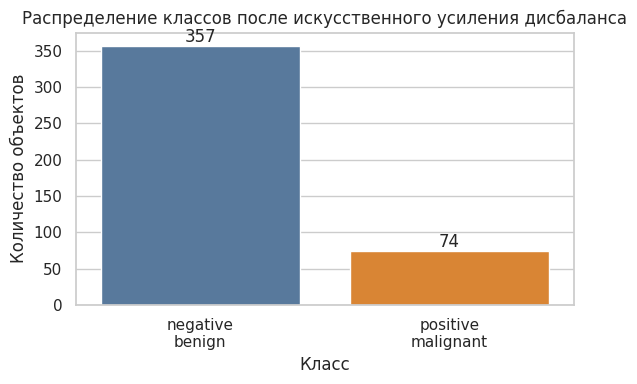

In [3]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y.map({0: "negative\nbenign", 1: "positive\nmalignant"}), palette=["#4C78A8", "#F58518"])
ax.set_title("Распределение классов после искусственного усиления дисбаланса")
ax.set_xlabel("Класс")
ax.set_ylabel("Количество объектов")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE,
)

pd.DataFrame({
    "train_count": y_train.value_counts().sort_index(),
    "train_share": y_train.value_counts(normalize=True).sort_index().round(3),
    "test_count": y_test.value_counts().sort_index(),
    "test_share": y_test.value_counts(normalize=True).sort_index().round(3),
}).rename(index={0: "negative / benign", 1: "positive / malignant"})


,train_count,train_share,test_count,test_share
target,,,,
negative / benign,249,0.827,108,0.831
positive / malignant,52,0.173,22,0.169


In [5]:
base_model = GradientBoostingClassifier(
    loss="log_loss",
    n_estimators=150,
    learning_rate=0.05,
    max_depth=2,
    random_state=RANDOM_STATE,
)
base_model.fit(X_train, y_train)

test_proba = base_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)


Матрица ошибок дает четыре числа:

- `TP` — положительный объект найден правильно.
- `TN` — отрицательный объект отклонен правильно.
- `FP` — отрицательный объект ошибочно принят за положительный.
- `FN` — положительный объект пропущен.

Метрики:

- `accuracy = (TP + TN) / (TP + TN + FP + FN)` показывает общую долю правильных ответов.
- `precision = TP / (TP + FP)` показывает, насколько надежны положительные предсказания.
- `recall = TP / (TP + FN)` показывает, какую долю реальных положительных объектов модель нашла.
- `specificity = TN / (TN + FP)` показывает, какую долю отрицательных объектов модель правильно отклонила.



In [6]:
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
specificity = tn / (tn + fp)
metrics_table = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall / sensitivity", "specificity"],
    "value": [
        accuracy_score(y_test, test_pred),
        precision_score(y_test, test_pred),
        recall_score(y_test, test_pred),
        specificity,
    ],
})
metrics_table


,metric,value
0,accuracy,0.953846
1,precision,0.900000
2,recall / sensitivity,0.818182
3,specificity,0.981481


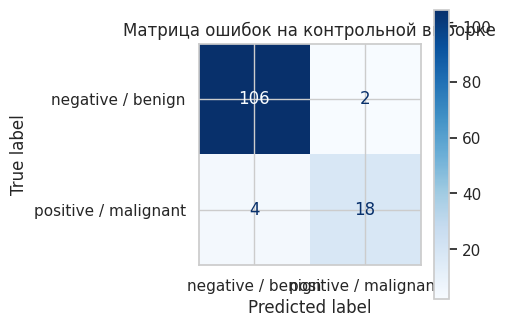

                      precision    recall  f1-score   support

   negative / benign       0.96      0.98      0.97       108
positive / malignant       0.90      0.82      0.86        22

            accuracy                           0.95       130
           macro avg       0.93      0.90      0.91       130
        weighted avg       0.95      0.95      0.95       130



In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=["negative / benign", "positive / malignant"],
    cmap="Blues",
    values_format="d",
    ax=ax,
)
ax.set_title("Матрица ошибок на контрольной выборке")
plt.tight_layout()
plt.show()

print(classification_report(y_test, test_pred, target_names=["negative / benign", "positive / malignant"]))


**TPR — True Positive Rate**, он же **recall / sensitivity / полнота**:TPR={TP}/{TP+FN} Значение TPR показывает, какую долю настоящих положительных объектов модель нашла. 
**FPR — False Positive Rate**, доля ложных срабатываний:FPR={FP}/{FP+TN}Значение FPR показывает, какую долю настоящих отрицательных объектов модель ошибочно назвала положительными.


ROC-кривая, согласно Wikipedia, строит `TPR` против `FPR` при изменении порога. Здесь `TPR` — recall, а `FPR = FP / (FP + TN) = 1 - specificity`. Чем ближе ROC-кривая к левому верхнему углу, тем лучше модель отделяет положительные объекты от отрицательных.

`roc_auc_score` считает площадь под ROC-кривой. Вероятностная интерпретация AUC: вероятность того, что случайный положительный объект получит оценку выше, чем случайный отрицательный.

Precision-Recall кривая показывает связь precision и recall при разных порогах. Для редкого положительного класса она часто информативнее ROC, потому что явно показывает цену ложноположительных срабатываний.


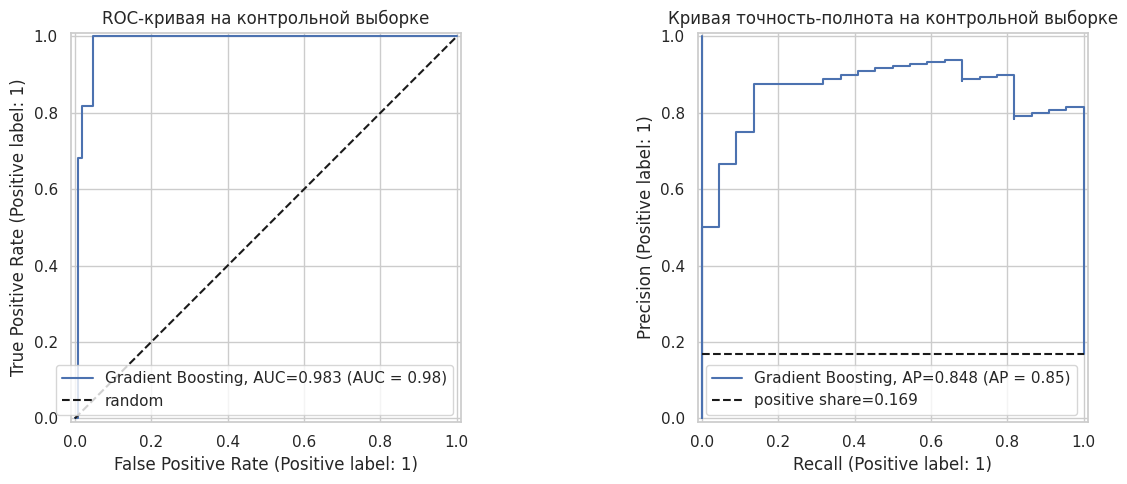

,metric,value
0,ROC AUC,0.982744
1,Average Precision / PR AUC summary,0.847800


In [8]:
roc_auc = roc_auc_score(y_test, test_proba)
avg_precision = average_precision_score(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_predictions(y_test, test_proba, ax=axes[0], name=f"Gradient Boosting, AUC={roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", label="random")
axes[0].set_title("ROC-кривая на контрольной выборке")
axes[0].legend(loc="lower right")

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_proba,
    ax=axes[1],
    name=f"Gradient Boosting, AP={avg_precision:.3f}",
)
baseline = y_test.mean()
axes[1].hlines(baseline, 0, 1, colors="k", linestyles="--", label=f"positive share={baseline:.3f}")
axes[1].set_title("Кривая точность-полнота на контрольной выборке")
axes[1].legend(loc="lower left")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "metric": ["ROC AUC", "Average Precision / PR AUC summary"],
    "value": [roc_auc, avg_precision],
})


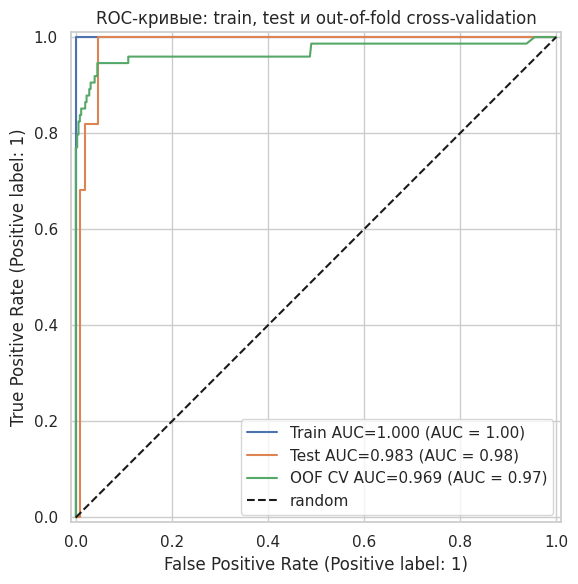

,sample,ROC AUC
0,train,1.000000
1,test,0.982744
2,cross-validation OOF,0.968923


In [9]:
train_proba = base_model.predict_proba(X_train)[:, 1]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_model = GradientBoostingClassifier(
    loss="log_loss",
    n_estimators=150,
    learning_rate=0.05,
    max_depth=2,
    random_state=RANDOM_STATE,
)
oof_proba = cross_val_predict(cv_model, X, y, cv=cv, method="predict_proba")[:, 1]

train_auc = roc_auc_score(y_train, train_proba)
test_auc = roc_auc_score(y_test, test_proba)
cv_auc = roc_auc_score(y, oof_proba)

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_train, train_proba, ax=ax, name=f"Train AUC={train_auc:.3f}")
RocCurveDisplay.from_predictions(y_test, test_proba, ax=ax, name=f"Test AUC={test_auc:.3f}")
RocCurveDisplay.from_predictions(y, oof_proba, ax=ax, name=f"OOF CV AUC={cv_auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", label="random")
ax.set_title("ROC-кривые: train, test и out-of-fold cross-validation")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "sample": ["train", "test", "cross-validation OOF"],
    "ROC AUC": [train_auc, test_auc, cv_auc],
})


In [10]:
models = {
    "GradientBoosting log_loss": GradientBoostingClassifier(
        loss="log_loss", n_estimators=150, learning_rate=0.05, max_depth=2, random_state=RANDOM_STATE
    ),
    "GradientBoosting exponential": GradientBoostingClassifier(
        loss="exponential", n_estimators=150, learning_rate=0.05, max_depth=2, random_state=RANDOM_STATE
    ),
    "AdaBoost SAMME": AdaBoostClassifier(
        n_estimators=150, learning_rate=0.05, algorithm="SAMME", random_state=RANDOM_STATE
    ),
    "LogisticRegression log_loss": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000, solver="lbfgs", random_state=RANDOM_STATE),
    ),
}

comparison_rows = []
comparison_probas = {}
for name, model in models.items():
    proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
    pred = (proba >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    comparison_probas[name] = proba
    comparison_rows.append({
        "model / criterion": name,
        "ROC AUC": roc_auc_score(y, proba),
        "Average Precision": average_precision_score(y, proba),
        "Accuracy@0.5": accuracy_score(y, pred),
        "Precision@0.5": precision_score(y, pred),
        "Recall@0.5": recall_score(y, pred),
        "Specificity@0.5": tn / (tn + fp),
    })

comparison = pd.DataFrame(comparison_rows).sort_values("ROC AUC", ascending=False).reset_index(drop=True)
comparison


,model / criterion,ROC AUC,Average Precision,Accuracy@0.5,Precision@0.5,Recall@0.5,Specificity@0.5
0,LogisticRegression log_loss,0.984821,0.972702,0.981439,0.971429,0.918919,0.994398
1,AdaBoost SAMME,0.969320,0.951177,0.960557,0.925373,0.837838,0.985994
2,GradientBoosting log_loss,0.968923,0.948422,0.962877,0.926471,0.851351,0.985994
3,GradientBoosting exponential,0.964532,0.946456,0.962877,0.939394,0.837838,0.988796


График накладывает ROC-кривые всех сравниваемых моделей на одну ось. Это позволяет увидеть не только итоговый AUC, но и форму кривой: одна модель может быть лучше при низком `FPR`, другая — при более высоком `FPR`.

Диагональная пунктирная линия соответствует случайному ранжированию. Кривая выше диагонали означает качество лучше случайного.


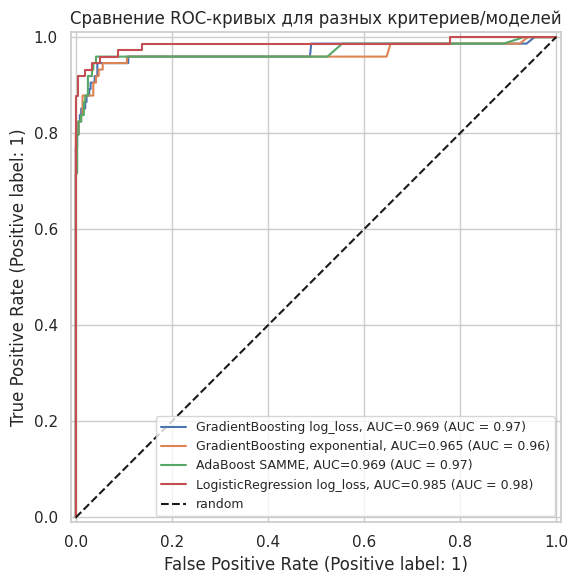

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in comparison_probas.items():
    auc_value = roc_auc_score(y, proba)
    RocCurveDisplay.from_predictions(y, proba, ax=ax, name=f"{name}, AUC={auc_value:.3f}")
ax.plot([0, 1], [0, 1], "k--", label="random")
ax.set_title("Сравнение ROC-кривых для разных критериев/моделей")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


In [12]:
weighted_model = GradientBoostingClassifier(
    loss="log_loss",
    n_estimators=150,
    learning_rate=0.05,
    max_depth=2,
    random_state=RANDOM_STATE,
)
sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
weighted_model.fit(X_train, y_train, sample_weight=sample_weight)

weighted_test_proba = weighted_model.predict_proba(X_test)[:, 1]
weighted_test_pred = (weighted_test_proba >= 0.5).astype(int)

def summarize_predictions(name, y_true, proba, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        "model": name,
        "ROC AUC": roc_auc_score(y_true, proba),
        "Average Precision": average_precision_score(y_true, proba),
        "Accuracy@0.5": accuracy_score(y_true, pred),
        "Precision@0.5": precision_score(y_true, pred),
        "Recall@0.5": recall_score(y_true, pred),
        "Specificity@0.5": tn / (tn + fp),
    }

weighted_comparison = pd.DataFrame([
    summarize_predictions("without weights", y_test, test_proba, test_pred),
    summarize_predictions("with balanced sample weights", y_test, weighted_test_proba, weighted_test_pred),
])
weighted_comparison


,model,ROC AUC,Average Precision,Accuracy@0.5,Precision@0.5,Recall@0.5,Specificity@0.5
0,without weights,0.982744,0.847800,0.953846,0.900000,0.818182,0.981481
1,with balanced sample weights,0.989057,0.960704,0.961538,0.869565,0.909091,0.972222


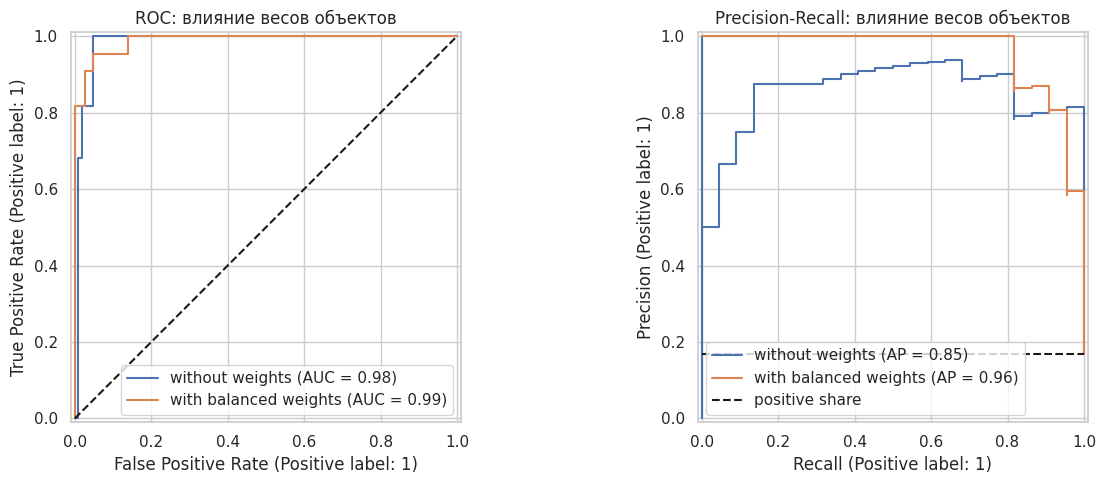

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_predictions(y_test, test_proba, ax=axes[0], name="without weights")
RocCurveDisplay.from_predictions(y_test, weighted_test_proba, ax=axes[0], name="with balanced weights")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("ROC: влияние весов объектов")
axes[0].legend(loc="lower right")

PrecisionRecallDisplay.from_predictions(y_test, test_proba, ax=axes[1], name="without weights")
PrecisionRecallDisplay.from_predictions(y_test, weighted_test_proba, ax=axes[1], name="with balanced weights")
axes[1].hlines(y_test.mean(), 0, 1, colors="k", linestyles="--", label="positive share")
axes[1].set_title("Precision-Recall: влияние весов объектов")
axes[1].legend(loc="lower left")
plt.tight_layout()
plt.show()
